# Проведём отбор признаков по кореляции с таргетом и по кореляции признаков между собой

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
target = 'amount_11_sum'

id = ['client_id', 'year_month']

exclude = ['client_id', 'year_month', 'amount_11_sum', 'amount_11_mean', 
           'amount_11_median', 'amount_11_std', 'amount_11_min', 
           'amount_11_max', 'tx_11_count', 'tx_total']

lag = ['lag1_amount_11_sum', 'lag1_amount_11_mean', 'lag1_amount_11_median', 'lag1_amount_11_std', 
       'lag1_amount_11_min', 'lag1_tx_11_count', 'lag1_tx_total', 'lag2_amount_11_sum', 
       'lag2_amount_11_mean', 'lag2_amount_11_median', 'lag2_amount_11_std', 
       'lag2_amount_11_min', 'lag2_tx_11_count', 'lag2_tx_total', 'lag3_amount_11_sum', 
       'lag3_amount_11_mean', 'lag3_amount_11_median', 'lag3_amount_11_std', 'lag3_amount_11_min', 
       'lag3_tx_11_count', 'lag3_tx_total', 'lag6_amount_11_sum', 'lag6_amount_11_mean', 
       'lag6_amount_11_median', 'lag6_amount_11_std', 'lag6_amount_11_min', 'lag6_tx_11_count', 
       'lag6_tx_total', 'lag9_amount_11_sum', 'lag9_amount_11_mean', 'lag9_amount_11_median', 
       'lag9_amount_11_std', 'lag9_amount_11_min', 'lag9_tx_11_count', 'lag9_tx_total', 
       'lag12_amount_11_sum', 'lag12_amount_11_mean', 'lag12_amount_11_median', 'lag12_amount_11_std', 
       'lag12_amount_11_min', 'lag12_tx_11_count', 'lag12_tx_total']

rolling = ['amount_11_sum_rolling_mean_3m', 'tx_11_count_rolling_mean_3m', 'tx_total_rolling_mean_3m', 
           'amount_11_sum_rolling_max_3m', 'amount_11_sum_rolling_min_3m', 'amount_11_sum_rolling_std_3m', 
           'amount_11_sum_rolling_mean_6m', 'tx_11_count_rolling_mean_6m', 'tx_total_rolling_mean_6m', 
           'amount_11_sum_rolling_max_6m', 'amount_11_sum_rolling_min_6m', 'amount_11_sum_rolling_std_6m', 
           'amount_11_sum_rolling_mean_12m', 'tx_11_count_rolling_mean_12m', 'tx_total_rolling_mean_12m', 
           'amount_11_sum_rolling_max_12m', 'amount_11_sum_rolling_min_12m', 'amount_11_sum_rolling_std_12m']
cummulative = ['amount_11_cumsum', 'tx_11_cumsum', 'tx_total_cumsum', 'amount_11_cummean', 
               'amount_11_hist_max', 'amount_11_hist_min', 'amount_11_hist_mean', 
               'amount_11_hist_std', 'tx_11_share_cum']

season = ['month', 'quarter', 'amount_11_same_month_last_year', 'is_quarter_start', 'is_quarter_end']

other = ['amount_11_pct_change_lag', 'amount_11_abs_change_lag', 'amount_11_vs_3m_avg_lag', 
         'amount_11_vs_cummean_lag', 'amount_11_vs_hist_max_lag', 'amount_11_vs_hist_min_lag', 
         'amount_11_hist_cv_lag', 'amount_11_hist_range_lag', 'amount_11_is_spike_lag', 
         'amount_11_is_dip_lag', 'amount_11_consecutive_growth_lag', 
         'amount_11_is_zero_lag', 'amount_11_active_ratio_lag']

event = ['src_type11_n_unique', 'src_type12_n_unique', 'src_type21_n_unique', 'src_type22_n_unique', 'src_type31_n_unique', 'src_type32_n_unique', 'dst_type11_n_unique', 'dst_type12_n_unique']

In [3]:
version = 3
df= pd.read_parquet(f"../data/processed/client_month_features_{version}.parquet")

In [4]:
# Объединяем все признаки (кроме exclude)
all_features = lag + rolling + cummulative + season + other + event

# Проверяем, что нет дубликатов и исключаем exclude
features_to_analyze = [f for f in all_features if f not in exclude]
print(f"Всего признаков для анализа: {len(features_to_analyze)}")

Всего признаков для анализа: 95


In [5]:
# Считаем корреляцию всех признаков с target
all_features = [col for col in df.columns if col not in exclude + [target]]
all_correlations = {}

for feature in all_features:
    if pd.api.types.is_numeric_dtype(df[feature]):
        corr = df[feature].corr(df[target])
        all_correlations[feature] = corr

corr_df = pd.DataFrame(list(all_correlations.items()), 
                       columns=['feature', 'target_corr'])
corr_df = corr_df.sort_values('target_corr', ascending=False)

print(f"Всего признаков: {len(all_features)}")
print(f"Из них числовых: {len(corr_df)}")

# Смотрим распределение корреляций
print("\nРаспределение корреляций с target:")
print(corr_df['target_corr'].describe())

# Признаки с очень низкой корреляцией
low_corr = corr_df[abs(corr_df['target_corr']) < 0.01]
print(f"\nПризнаков с |corr| < 0.01: {len(low_corr)}")
if len(low_corr) > 0:
    print("Примеры:", low_corr['feature'].head(10).tolist())

Всего признаков: 95
Из них числовых: 95

Распределение корреляций с target:
count    95.000000
mean      0.156997
std       0.171595
min      -0.027306
25%       0.008624
50%       0.110955
75%       0.250106
max       0.586493
Name: target_corr, dtype: float64

Признаков с |corr| < 0.01: 24
Примеры: ['amount_11_vs_hist_max_lag', 'amount_11_active_ratio_lag', 'amount_11_consecutive_growth_lag', 'amount_11_vs_3m_avg_lag', 'lag1_amount_11_min', 'lag12_amount_11_median', 'amount_11_hist_cv_lag', 'lag9_amount_11_median', 'lag3_amount_11_median', 'lag12_amount_11_min']


In [6]:
# Строим матрицу корреляций для всех признаков
# (но визуализируем выборочно, т.к. полная матрица может быть огромной)

# Находим проблемные пары среди всех признаков
threshold = 0.95
high_corr_pairs = []

for i in range(len(all_features)):
    for j in range(i+1, len(all_features)):
        f1, f2 = all_features[i], all_features[j]
        if f1 in df.columns and f2 in df.columns:
            if pd.api.types.is_numeric_dtype(df[f1]) and pd.api.types.is_numeric_dtype(df[f2]):
                corr = df[f1].corr(df[f2])
                if abs(corr) > threshold:
                    high_corr_pairs.append({
                        'feature1': f1,
                        'feature2': f2,
                        'correlation': corr,
                        'target_corr1': all_correlations.get(f1, 0),
                        'target_corr2': all_correlations.get(f2, 0)
                    })

high_corr_df = pd.DataFrame(high_corr_pairs)
high_corr_df = high_corr_df.sort_values('correlation', ascending=False)

print(f"\nНайдено пар с корреляцией > {threshold}: {len(high_corr_pairs)}")

# Группируем по признакам, чтобы найти "проблемные"
problem_features = pd.Series(
    [item for sublist in 
     [(p['feature1'], p['feature2']) for p in high_corr_pairs] 
     for item in sublist]
).value_counts()

print("\nТоп-10 признаков, чаще всего участвующих в сильных связях:")
print(problem_features.head(10))

/home/margo/A/projects/python/client_activity_forecast/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/margo/A/projects/python/client_activity_forecast/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Найдено пар с корреляцией > 0.95: 96

Топ-10 признаков, чаще всего участвующих в сильных связях:
tx_11_count_rolling_mean_6m     13
tx_11_count_rolling_mean_12m    13
tx_total_rolling_mean_6m        13
tx_total_rolling_mean_12m       13
tx_11_count_rolling_mean_3m     11
tx_total_rolling_mean_3m        11
lag1_tx_11_count                 7
lag2_tx_total                    7
lag3_tx_11_count                 7
lag1_tx_total                    7
Name: count, dtype: int64


/tmp/ipykernel_48488/1349586294.py:20: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = hierarchy.linkage(distances, method='average')


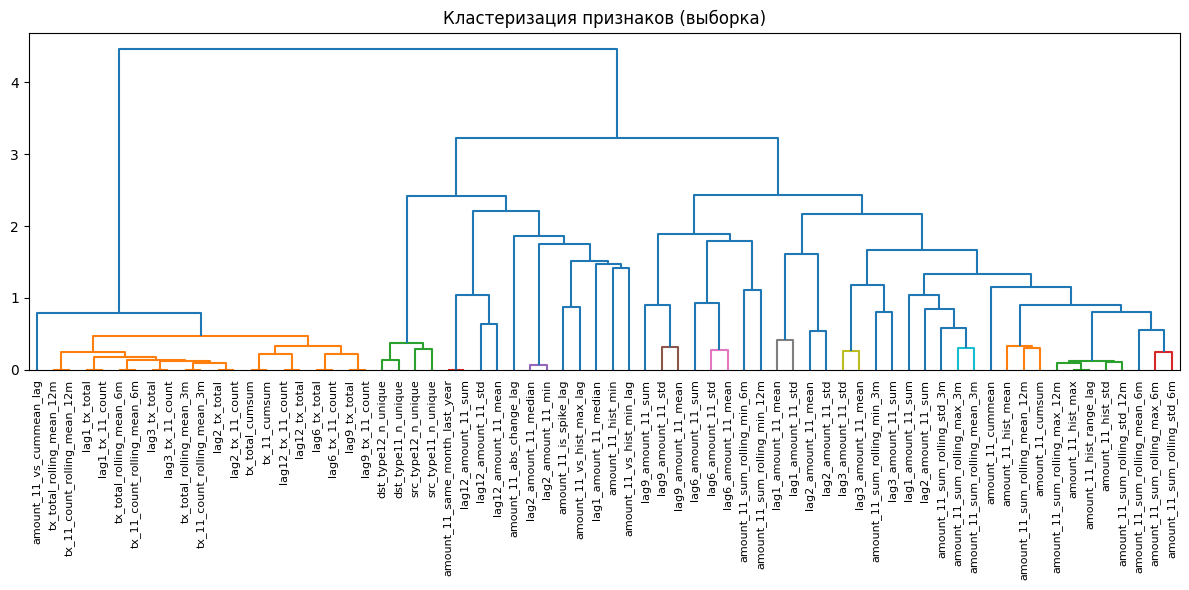

In [9]:
# Иерархическая кластеризация для всех признаков
# (но визуализируем компактно)

from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

m_f = 70
# Берем выборку признаков для визуализации (если их очень много)
if len(all_features) > m_f:
    # Оставляем топ-m_f по важности или случайные
    sample_features = corr_df.head(m_f)['feature'].tolist()
else:
    sample_features = all_features

# Матрица корреляций для выборки
sample_corr = df[sample_features].corr().values

# Кластеризация
distances = 1 - abs(sample_corr)
linkage_matrix = hierarchy.linkage(distances, method='average')

# Компактная визуализация
plt.figure(figsize=(12, 6))
hierarchy.dendrogram(
    linkage_matrix,
    labels=sample_features,
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=0.5
)
plt.title('Кластеризация признаков (выборка)')
plt.tight_layout()
plt.show()

In [12]:
# Найдите все идеальные дубликаты (corr = 1.0)
perfect_duplicates = []
for pair in high_corr_pairs:
    if abs(pair['correlation']) > 0.999:
        perfect_duplicates.append(pair['feature2'])  # удаляем второй признак

print(f"Идеальных дубликатов: {len(perfect_duplicates)}")

# Для LGBM удалим только идеальные дубликаты
features_to_drop = perfect_duplicates

# Для остальных сильных связей (>0.95) - не удаляем
# Просто используем colsample_bytree, чтобы модель видела разные комбинации, сделаем forward feature selection
# Признаки с очень низкой корреляцией с target (<0.01) Не удаляем автоматически
# Смотрим на корреляции  целиком

print(f"\nВсего признаков: {len(all_features)}")
print(f"Пар с corr > 0.95: {len(high_corr_pairs)}")
print(f"Уникальных признаков в этих парах: {len(problem_features)}")

Идеальных дубликатов: 14

Всего признаков: 95
Пар с corr > 0.95: 96
Уникальных признаков в этих парах: 55


In [13]:
# Удаляем 14 признаков, у которых есть точные копии
# Это безопасно - информация не теряется

features_to_drop_1 = perfect_duplicates  # ваши 14 признаков
print(f"Удаляем идеальные дубликаты: {features_to_drop_1}")

Удаляем идеальные дубликаты: ['lag1_tx_total', 'lag2_tx_total', 'lag3_tx_total', 'lag6_tx_total', 'lag9_tx_total', 'amount_11_same_month_last_year', 'lag12_tx_total', 'tx_total_rolling_mean_3m', 'tx_total_rolling_mean_6m', 'tx_total_rolling_mean_12m', 'tx_total_cumsum', 'amount_11_hist_range_lag', 'src_type22_n_unique', 'src_type32_n_unique']


In [14]:
# Создаем граф связей
import networkx as nx

# Берем все пары с corr > 0.95 (кроме идеальных)
strong_pairs = [p for p in high_corr_pairs if abs(p['correlation']) < 0.999]

# Строим граф
G = nx.Graph()
for pair in strong_pairs:
    G.add_edge(pair['feature1'], pair['feature2'], weight=pair['correlation'])

# Находим компоненты связности (кластеры)
clusters = list(nx.connected_components(G))
print(f"Найдено {len(clusters)} кластеров сильно связанных признаков:")

for i, cluster in enumerate(clusters):
    print(f"\nКластер {i+1} ({len(cluster)} признаков):")
    for feat in sorted(cluster)[:5]:  # покажем первые 5
        print(f"  - {feat}")
    if len(cluster) > 5:
        print(f"    ... и еще {len(cluster)-5}")

Найдено 14 кластеров сильно связанных признаков:

Кластер 1 (2 признаков):
  - lag1_amount_11_median
  - lag1_amount_11_min

Кластер 2 (14 признаков):
  - lag1_tx_11_count
  - lag1_tx_total
  - lag2_tx_11_count
  - lag2_tx_total
  - lag3_tx_11_count
    ... и еще 9

Кластер 3 (2 признаков):
  - lag2_amount_11_median
  - lag2_amount_11_min

Кластер 4 (2 признаков):
  - lag3_amount_11_median
  - lag3_amount_11_min

Кластер 5 (2 признаков):
  - lag6_amount_11_median
  - lag6_amount_11_min

Кластер 6 (2 признаков):
  - lag9_amount_11_median
  - lag9_amount_11_min

Кластер 7 (2 признаков):
  - lag12_amount_11_median
  - lag12_amount_11_min

Кластер 8 (3 признаков):
  - amount_11_sum_rolling_max_3m
  - amount_11_sum_rolling_mean_3m
  - amount_11_sum_rolling_std_3m

Кластер 9 (2 признаков):
  - amount_11_sum_rolling_max_6m
  - amount_11_sum_rolling_std_6m

Кластер 10 (3 признаков):
  - amount_11_cumsum
  - amount_11_hist_mean
  - amount_11_sum_rolling_mean_12m

Кластер 11 (5 признаков):
  - a

In [20]:
def select_best_from_cluster(cluster_features, target_corr_dict):
    """
    Выбирает из кластера признак с максимальной абсолютной корреляцией с target
    """
    cluster_with_corr = []
    for feat in cluster_features:
        if feat in target_corr_dict:
            abs_corr = abs(target_corr_dict[feat])
            cluster_with_corr.append({
                'feature': feat,
                'target_corr': target_corr_dict[feat],
                'abs_target_corr': abs_corr
            })
    
    if not cluster_with_corr:
        return []
    
    # Сортируем по абсолютной корреляции
    cluster_with_corr.sort(key=lambda x: x['abs_target_corr'], reverse=True)
    
    # Берем только лучший признак из кластера
    best_feature = cluster_with_corr[0]['feature']
    print(f"    Выбран: {best_feature} (corr={cluster_with_corr[0]['target_corr']:.4f})")
    
    # Возвращаем список остальных признаков кластера для удаления
    return [f['feature'] for f in cluster_with_corr[1:]]


# Создаем словарь для хранения лучших признаков из каждого кластера
best_features = []
features_to_drop_from_clusters = []

print("\n" + "="*60)
print("АНАЛИЗ КЛАСТЕРОВ И ВЫБОР ЛУЧШИХ ПРИЗНАКОВ:")
print("="*60)

# Обрабатываем каждый кластер
for i, cluster in enumerate(clusters):
    print(f"\nКластер {i+1} ({len(cluster)} признаков):")
    
    # Получаем признаки для удаления из этого кластера
    to_drop = select_best_from_cluster(cluster, all_correlations)
    features_to_drop_from_clusters.extend(to_drop)
    
    # Запоминаем лучший признак (он не будет удален)
    best_in_cluster = list(cluster - set(to_drop))[0] if to_drop else list(cluster)[0]
    best_features.append(best_in_cluster)

# Добавляем признаки, которые не вошли ни в один кластер
all_clustered_features = set()
for cluster in clusters:
    all_clustered_features.update(cluster)

lonely_features = set(all_features) - all_clustered_features - set(perfect_duplicates)
print(f"\n" + "="*60)
print(f"Признаков вне кластеров: {len(lonely_features)}")
for feat in sorted(lonely_features)[:10]:
    print(f"  - {feat}")



АНАЛИЗ КЛАСТЕРОВ И ВЫБОР ЛУЧШИХ ПРИЗНАКОВ:

Кластер 1 (2 признаков):
    Выбран: lag1_amount_11_median (corr=0.0109)

Кластер 2 (14 признаков):
    Выбран: tx_total_rolling_mean_12m (corr=0.1350)

Кластер 3 (2 признаков):
    Выбран: lag2_amount_11_median (corr=0.0139)

Кластер 4 (2 признаков):
    Выбран: lag3_amount_11_median (corr=0.0023)

Кластер 5 (2 признаков):
    Выбран: lag6_amount_11_median (corr=0.0021)

Кластер 6 (2 признаков):
    Выбран: lag9_amount_11_median (corr=0.0029)

Кластер 7 (2 признаков):
    Выбран: lag12_amount_11_median (corr=0.0051)

Кластер 8 (3 признаков):
    Выбран: amount_11_sum_rolling_max_3m (corr=0.5490)

Кластер 9 (2 признаков):
    Выбран: amount_11_sum_rolling_max_6m (corr=0.4998)

Кластер 10 (3 признаков):
    Выбран: amount_11_hist_mean (corr=0.4634)

Кластер 11 (5 признаков):
    Выбран: amount_11_sum_rolling_max_12m (corr=0.4477)

Кластер 12 (2 признаков):
    Выбран: quarter (corr=0.0004)

Кластер 13 (4 признаков):
    Выбран: src_type32_n_u

In [22]:

# Объединяем все признаки для удаления
all_features_to_drop = set(perfect_duplicates + features_to_drop_from_clusters)

# Финальный список признаков для сохранения
final_features = set(all_features) - all_features_to_drop

print("\n" + "="*60)
print("ИТОГОВАЯ СТАТИСТИКА:")
print("="*60)
print(f"Всего признаков в исходном датасете: {len(all_features)}")
print(f"Удалено идеальных дубликатов: {len(perfect_duplicates)}")
print(f"Удалено из кластеров (оставлен лучший): {len(features_to_drop_from_clusters)}")
print(f"Всего удалено признаков: {len(all_features_to_drop)}")
print(f"Оставлено признаков (кроме целевого и id): {len(final_features)}")
print(f"Сокращение: {(1 - len(final_features)/len(all_features))*100:.1f}%")

# Создаем новый датасет только с отобранными признаками + target + id
df_clean = df[list(final_features) + id + [target]].copy()

print(f"\nРазмерность нового датасета: {df_clean.shape}")


# Сохраняем новый датасет
new_version = 4
output_path = f"../data/processed/client_month_features_{new_version}.parquet"
df_clean.to_parquet(output_path, index=False)

print(f"\n" + "="*60)
print(f"ДАТАСЕТ СОХРАНЕН: {output_path}")
print("="*60)

# Сохраняем список удаленных признаков для документации
deleted_df = pd.DataFrame({
    'feature': list(all_features_to_drop),
    'reason': ['perfect_duplicate' if f in perfect_duplicates else 'cluster_redundant' for f in all_features_to_drop]
})
deleted_df.to_csv(f"../data/processed/deleted_features_v{new_version}.csv", index=False)
print(f"\nСписок удаленных признаков сохранен в deleted_features_v{new_version}.csv")


ИТОГОВАЯ СТАТИСТИКА:
Всего признаков в исходном датасете: 95
Удалено идеальных дубликатов: 14
Удалено из кластеров (оставлен лучший): 33
Всего удалено признаков: 39
Оставлено признаков (кроме целевого и id): 56
Сокращение: 41.1%

Размерность нового датасета: (500800, 59)

ДАТАСЕТ СОХРАНЕН: ../data/processed/client_month_features_4.parquet

Список удаленных признаков сохранен в deleted_features_v4.csv
